# Actividad 1 — Regresión Lineal Múltiple
## Predicción de Gastos Médicos

**Objetivo:** Predecir los gastos médicos (`charges`) de un paciente a partir de variables como edad, condición de fumador, IMC, número de hijos y región.

**Dataset:** Medical Cost Personal Dataset — variables: `age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges`.

**Método:**
1. Preparación y organización de datos
2. Exploración de los datos
4. Modelado de datos

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import explained_variance_score
import seaborn as sns
import sklearn.metrics as sm

## 2. Carga del dataset

In [2]:
# Cargamos el dataset
df = pd.read_csv(r'C:\Users\usuario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\01 - Ejercicios Entrega\Semana 4\Insurance.csv', encoding="ISO-8859-1")
print('Shape del dataset:', df.shape)
df.head()

Shape del dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Exploración de los datos

In [3]:
# Información general del dataset
print('Forma del dataset:', df.shape)
print('\nInformación general:')
df.info()
df.describe()
print(df.isnull().sum())

Forma del dataset: (1338, 7)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


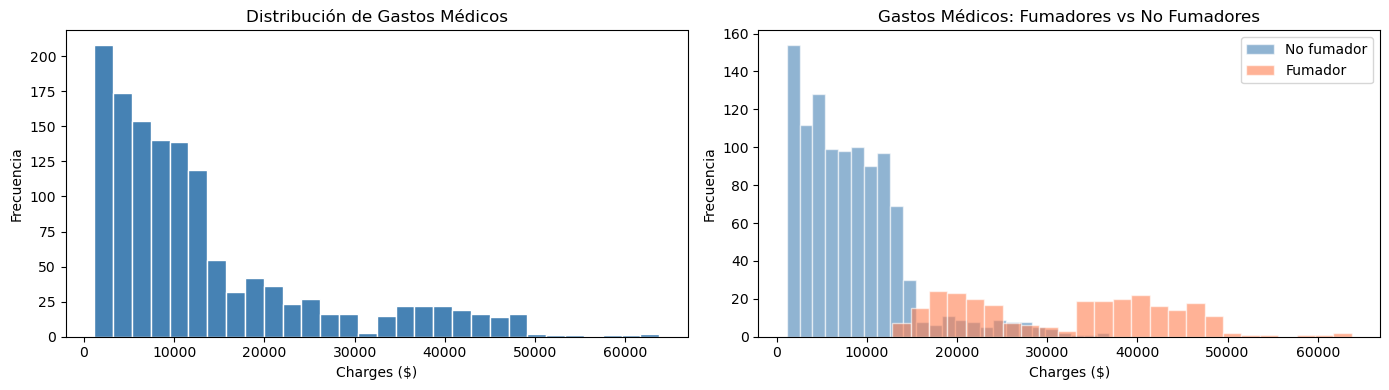

In [4]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['charges'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Gastos Médicos')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frecuencia')

# Gastos por condición de fumador
fumadores = df[df['smoker'] == 'yes']['charges']
no_fumadores = df[df['smoker'] == 'no']['charges']
axes[1].hist(no_fumadores, bins=25, alpha=0.6, label='No fumador', color='steelblue', edgecolor='white')
axes[1].hist(fumadores, bins=25, alpha=0.6, label='Fumador', color='coral', edgecolor='white')
axes[1].set_title('Gastos Médicos: Fumadores vs No Fumadores')
axes[1].set_xlabel('Charges ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

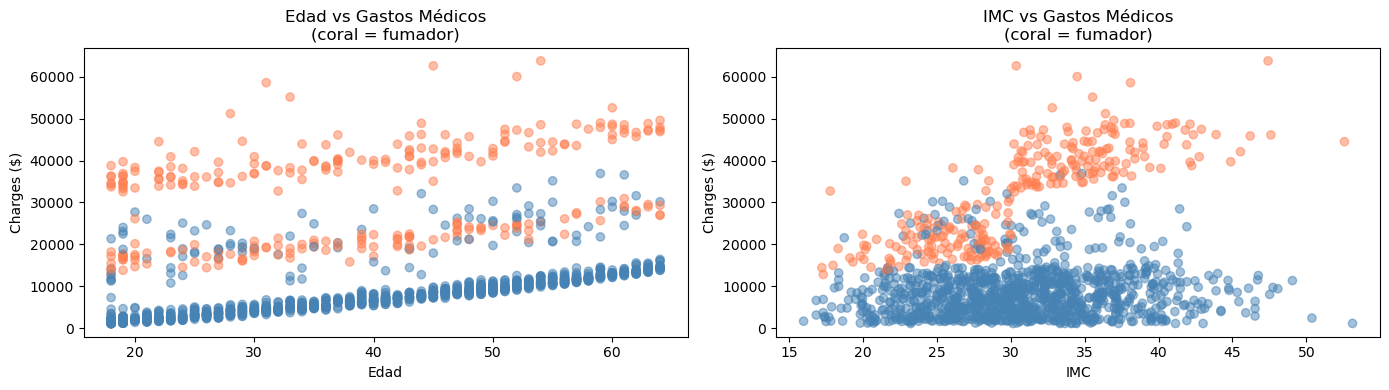

In [5]:
# Relación entre edad, IMC y gastos médicos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = df['smoker'].map({'yes': 'coral', 'no': 'steelblue'})

axes[0].scatter(df['age'], df['charges'], c=colors, alpha=0.5)
axes[0].set_title('Edad vs Gastos Médicos\n(coral = fumador)')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Charges ($)')

axes[1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.5)
axes[1].set_title('IMC vs Gastos Médicos\n(coral = fumador)')
axes[1].set_xlabel('IMC')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

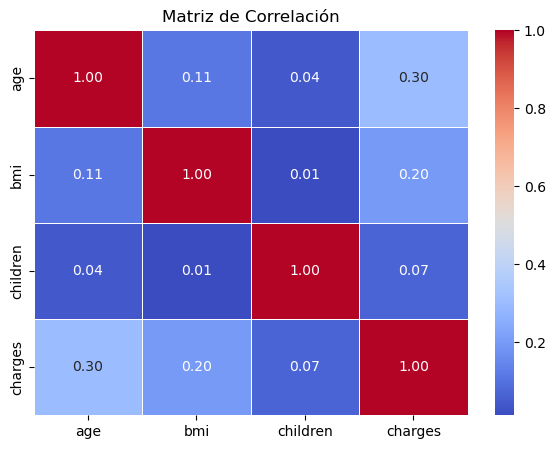

In [6]:
# Matriz de correlación
corr = df.select_dtypes(include=['number']).corr()

# Gráfico
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",linewidths=0.5)     
plt.title("Matriz de Correlación")
plt.show()

## 4. Preparación de datos

Las variables categóricas (`sex`, `smoker`, `region`) se convierten a numéricas mediante codificación. Luego se dividen los datos en entrenamiento (80%) y prueba (20%) con mezcla aleatoria.

In [7]:
# Convertir variable categorica a numerica
le = LabelEncoder()
df['smoker'] = le.fit_transform(df['smoker'])
df['sex'] = le.fit_transform(df['sex'])
df['region'] = df['region'].map({
    'northeast': 0, 'northwest': 1,
    'southeast': 2, 'southwest': 3
})

print('Dataset después de codificación:')
df.head()

Dataset después de codificación:


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [8]:
# Variables predictoras(x) y variable objetivo(y)
X = df.drop("charges", axis=1)
y = df["charges"]

# División aleatoria: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Datos de entrenamiento: {len(X_train)} registros')
print(f'Datos de prueba:        {len(X_test)} registros')


Datos de entrenamiento: 1070 registros
Datos de prueba:        268 registros


## 5. Entrenamiento del modelo

In [9]:
# === 7. MODELADO ===
model = LinearRegression()
model.fit(X_train, y_train)

# === 8. PREDICCIÓN Y EVALUACIÓN ===
y_pred = model.predict(X_test)
print("Intercepto:", model.intercept_)
print("Coeficiente:", model.coef_)

Intercepto: -11946.606567263016
Coeficiente: [ 2.57056264e+02 -1.87914567e+01  3.35781491e+02  4.25091456e+02
  2.36478181e+04 -2.71284266e+02]


## 6. Evaluación del modelo

In [10]:
print("\nEvaluación del modelo (Regresión Simple):")
print(f"MAE - Error Absoluto Medio: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE - Error Cuadratico Medio: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R² - Coefeciente de determinacion: {r2_score(y_test, y_pred):.4f}")
print(f"Varianza explicada: {explained_variance_score(y_test, y_pred):.4f}")


Evaluación del modelo (Regresión Simple):
MAE - Error Absoluto Medio: 4186.5089
MSE - Error Cuadratico Medio: 33635210.4312
R² - Coefeciente de determinacion: 0.7833
Varianza explicada: 0.7837


## 7. Visualización de resultados

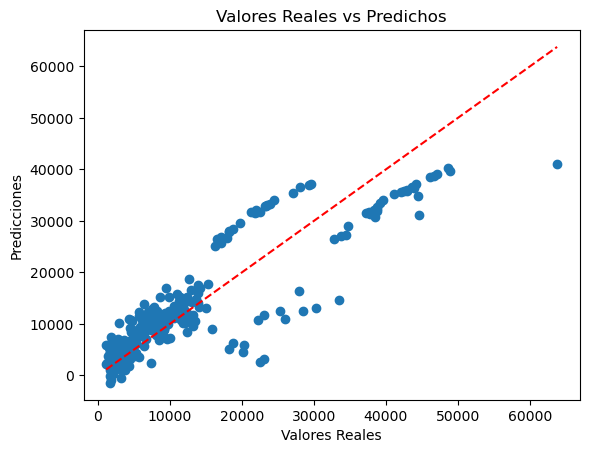

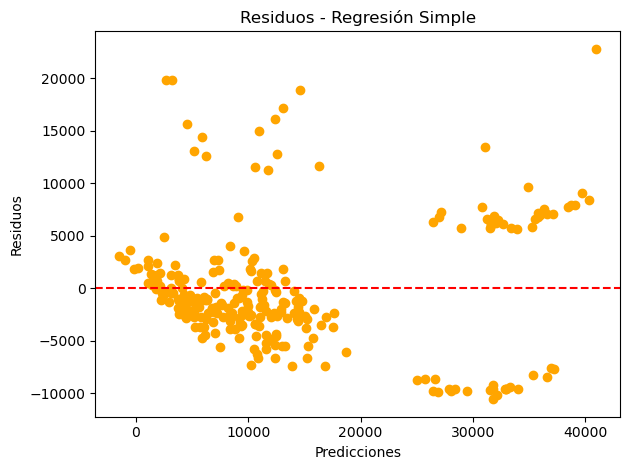

In [11]:

# Valores reales vs predichos
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predichos")
plt.show()

# Residuos
residuos = y_test - y_pred
plt.scatter(y_pred, residuos, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.title("Residuos - Regresión Simple")
plt.tight_layout()
plt.show()



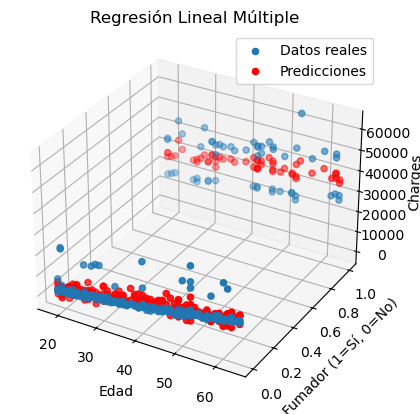

In [12]:
# Visualización 3D: Edad, Fumador y Charges
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test['age'], X_test['smoker'], y_test, label="Datos reales")
ax.scatter(X_test['age'], X_test['smoker'], y_pred, color='red', label="Predicciones")

ax.set_xlabel("Edad")
ax.set_ylabel("Fumador (1=Sí, 0=No)")
ax.set_zlabel("Charges")

plt.title("Regresión Lineal Múltiple")
plt.legend()
plt.show()


## Datos de Prueba

In [14]:
# ── DATOS DE PRUEBA 
# Perfil 1: joven, no fumador, IMC normal
# Perfil 2: adulto mayor, fumador, IMC alto
# Perfil 3: mujer joven, no fumadora, IMC normal
# Perfil 4: adulto, fumador, IMC bajo
# Perfil 5: adulto mayor, no fumador, muchos hijos

import pandas as pd

prueba = pd.DataFrame({
    'age':      [22,  60,  28,  45,  55],
    'sex':      [1,   1,   0,   1,   0],   # 1=male, 0=female
    'bmi':      [24.5, 38.2, 22.1, 29.0, 31.5],
    'children': [0,   0,   1,   2,   4],
    'smoker':   [0,   1,   0,   1,   0],   # 1=yes, 0=no
    'region':   [0,   2,   1,   3,   0]    # 0=NE,1=NW,2=SE,3=SW
})

predicciones = model.predict(prueba)

for i, pred in enumerate(predicciones):
    print(f"Perfil {i+1}: ${pred:,.2f}")

Perfil 1: $1,916.49
Perfil 2: $39,390.08
Perfil 3: $2,825.55
Perfil 4: $33,023.95
Perfil 5: $14,468.97


## Conclusión

En conclusión, el ejercicio permitió construir un modelo de Regresión Lineal Múltiple para estimar gastos médicos a partir de distintas características personales y de cobertura. El modelo obtuvo un resultado aceptable, ya que logró explicar cerca del 78% de la variación de los costos médicos.

El análisis muestra que la variable más influyente es la condición de fumador, seguida por la edad y el índice de masa corporal. Esto se refleja también en las predicciones de prueba, donde los perfiles fumadores presentan valores mucho más altos que los no fumadores.

Si bien el modelo funciona correctamente como primera aproximación, todavía puede mejorarse incorporando más análisis, probando otros modelos o revisando posibles valores extremos. El objetivo principal: aplicar regresión lineal múltiple para predecir gastos médicos y analizar qué variables tienen mayor impacto en esa predicción.